In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.22.0-rc0


In [2]:
# File paths

train_file = "CICIOT23/train/train.csv"
val_file = "CICIOT23/validation/validation.csv"
test_file = "CICIOT23/test/test.csv" 

In [3]:
#Load Dataset
train_df = pd.read_csv(train_file)
val_df = pd.read_csv(val_file)
test_df = pd.read_csv(test_file)

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
display(train_df.head())

Training shape: (5491971, 47)
Validation shape: (1176851, 47)
Testing shape: (1176851, 47)

Training columns:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

First 5 rows:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
#Find the target/label column
possible_target_columns = [
    "label",
    "Label",
    "class",
    "Class",
    "target",
    "Target",
    "attack",
    "Attack",
    "category",
    "Category"
]

target_column = None

for col in possible_target_columns:
    if col in train_df.columns:
        target_column = col
        break

if target_column is None:
    print("Could not automatically find the target column.")
    print("Available columns:")
    print(train_df.columns.tolist())
else:
    print("Target column:", target_column)

Target column: label


In [5]:
#Separate features and target
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_val = val_df.drop(columns=[target_column])
y_val = val_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5491971, 46)
y_train: (5491971,)
X_val: (1176851, 46)
y_val: (1176851,)
X_test: (1176851, 46)
y_test: (1176851,)


In [6]:
#Handle missing and non-numeric values
# Keep only columns that are common to all three datasets
common_features = (
    set(X_train.columns)
    & set(X_val.columns)
    & set(X_test.columns)
)

common_features = list(common_features)

X_train = X_train[common_features]
X_val = X_val[common_features]
X_test = X_test[common_features]

# Convert feature columns to numeric
for col in common_features:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_val[col] = pd.to_numeric(X_val[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

# Replace infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill missing values using training-set medians
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Preprocessing completed.")
print("Number of features:", X_train.shape[1])

Preprocessing completed.
Number of features: 46


In [7]:
#Encode the labels
label_encoder = LabelEncoder()

# Fit only on training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Handle labels in validation/test
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, "=", name)

Number of classes: 34
Classes:
0 = Backdoor_Malware
1 = BenignTraffic
2 = BrowserHijacking
3 = CommandInjection
4 = DDoS-ACK_Fragmentation
5 = DDoS-HTTP_Flood
6 = DDoS-ICMP_Flood
7 = DDoS-ICMP_Fragmentation
8 = DDoS-PSHACK_Flood
9 = DDoS-RSTFINFlood
10 = DDoS-SYN_Flood
11 = DDoS-SlowLoris
12 = DDoS-SynonymousIP_Flood
13 = DDoS-TCP_Flood
14 = DDoS-UDP_Flood
15 = DDoS-UDP_Fragmentation
16 = DNS_Spoofing
17 = DictionaryBruteForce
18 = DoS-HTTP_Flood
19 = DoS-SYN_Flood
20 = DoS-TCP_Flood
21 = DoS-UDP_Flood
22 = MITM-ArpSpoofing
23 = Mirai-greeth_flood
24 = Mirai-greip_flood
25 = Mirai-udpplain
26 = Recon-HostDiscovery
27 = Recon-OSScan
28 = Recon-PingSweep
29 = Recon-PortScan
30 = SqlInjection
31 = Uploading_Attack
32 = VulnerabilityScan
33 = XSS


In [9]:
#Normalize the input features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Training data shape:", X_train_scaled.shape)

Feature scaling completed.
Training data shape: (5491971, 46)


In [19]:


# Build the neural network
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │         1,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,474 (68.26 KB)

 Trainable params: 17,474 (68.26 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Train the neural network
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_val_scaled, y_val_encoded),
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.8540 - loss: 0.3440 - val_accuracy: 0.9510 - val_loss: 0.1297
Epoch 2/20
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9420 - loss: 0.1524 - val_accuracy: 0.9338 - val_loss: 0.1632
Epoch 3/20
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 65s 2ms/step - accuracy: 0.9411 - loss: 0.1538 - val_accuracy: 0.9527 - val_loss: 0.1407
Epoch 4/20
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.9546 - loss: 0.1231 - val_accuracy: 0.9225 - val_loss: 0.1976


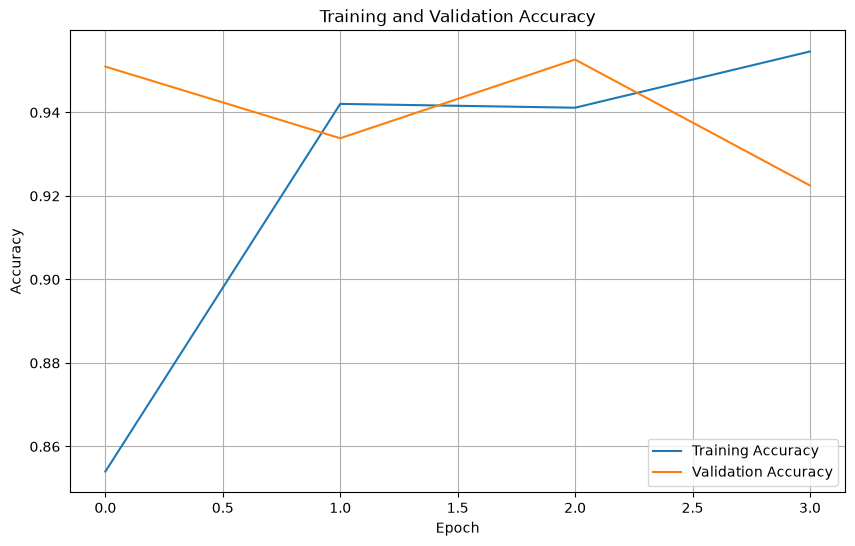

In [38]:
#Plot training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

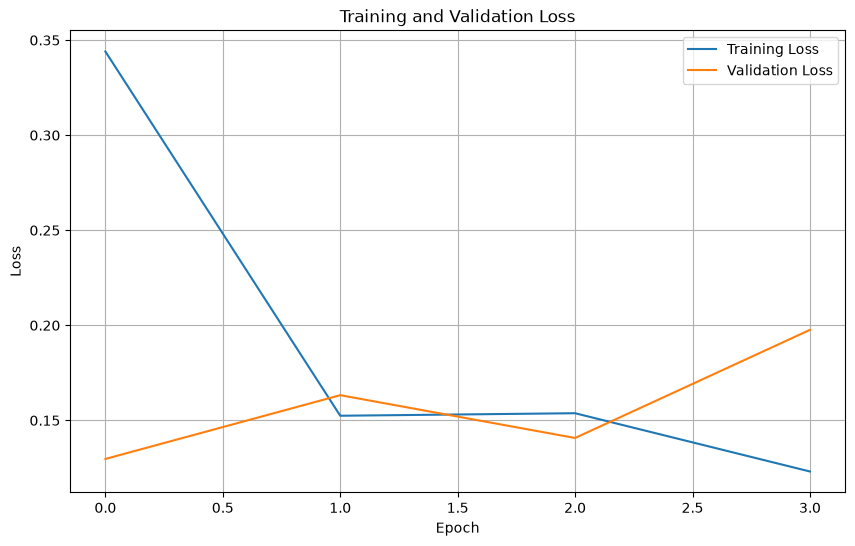

In [37]:
#Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)


plt.show()

In [23]:
#Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

36777/36777 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step - accuracy: 0.9504 - loss: 0.1306
Test Loss: 0.13059738278388977
Test Accuracy: 0.9503768682479858


In [24]:
#Generate predictions
y_probability = model.predict(X_test_scaled)

y_pred_encoded = np.argmax(y_probability, axis=1)

print("Predictions generated.")

36777/36777 ━━━━━━━━━━━━━━━━━━━━ 31s 843us/step
Predictions generated.


In [25]:
#Calculate precision, recall and F-score
precision = precision_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted",
    zero_division=0
)

accuracy = accuracy_score(
    y_test_encoded,
    y_pred_encoded
)

print("Performance Results")
print("--------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Performance Results
--------------------
Accuracy  : 0.9504
Precision : 0.9513
Recall    : 0.9504
F1-score  : 0.9418


In [26]:
#Detailed classification report
report = classification_report(
    y_test_encoded,
    y_pred_encoded,
    target_names=class_names,
    zero_division=0
)

print(report)

                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00        89
          BenignTraffic       0.71      0.99      0.83     27709
       BrowserHijacking       0.00      0.00      0.00       134
       CommandInjection       0.00      0.00      0.00       119
 DDoS-ACK_Fragmentation       0.99      0.98      0.99      7292
        DDoS-HTTP_Flood       0.59      0.52      0.55       709
        DDoS-ICMP_Flood       1.00      1.00      1.00    180447
DDoS-ICMP_Fragmentation       0.99      0.98      0.98     11402
      DDoS-PSHACK_Flood       1.00      1.00      1.00    103326
       DDoS-RSTFINFlood       1.00      1.00      1.00    101819
         DDoS-SYN_Flood       0.98      0.92      0.95    102208
         DDoS-SlowLoris       0.42      0.56      0.48       622
DDoS-SynonymousIP_Flood       0.96      0.99      0.98     90480
         DDoS-TCP_Flood       1.00      0.98      0.99    113735
         DDoS-UDP_Flood 

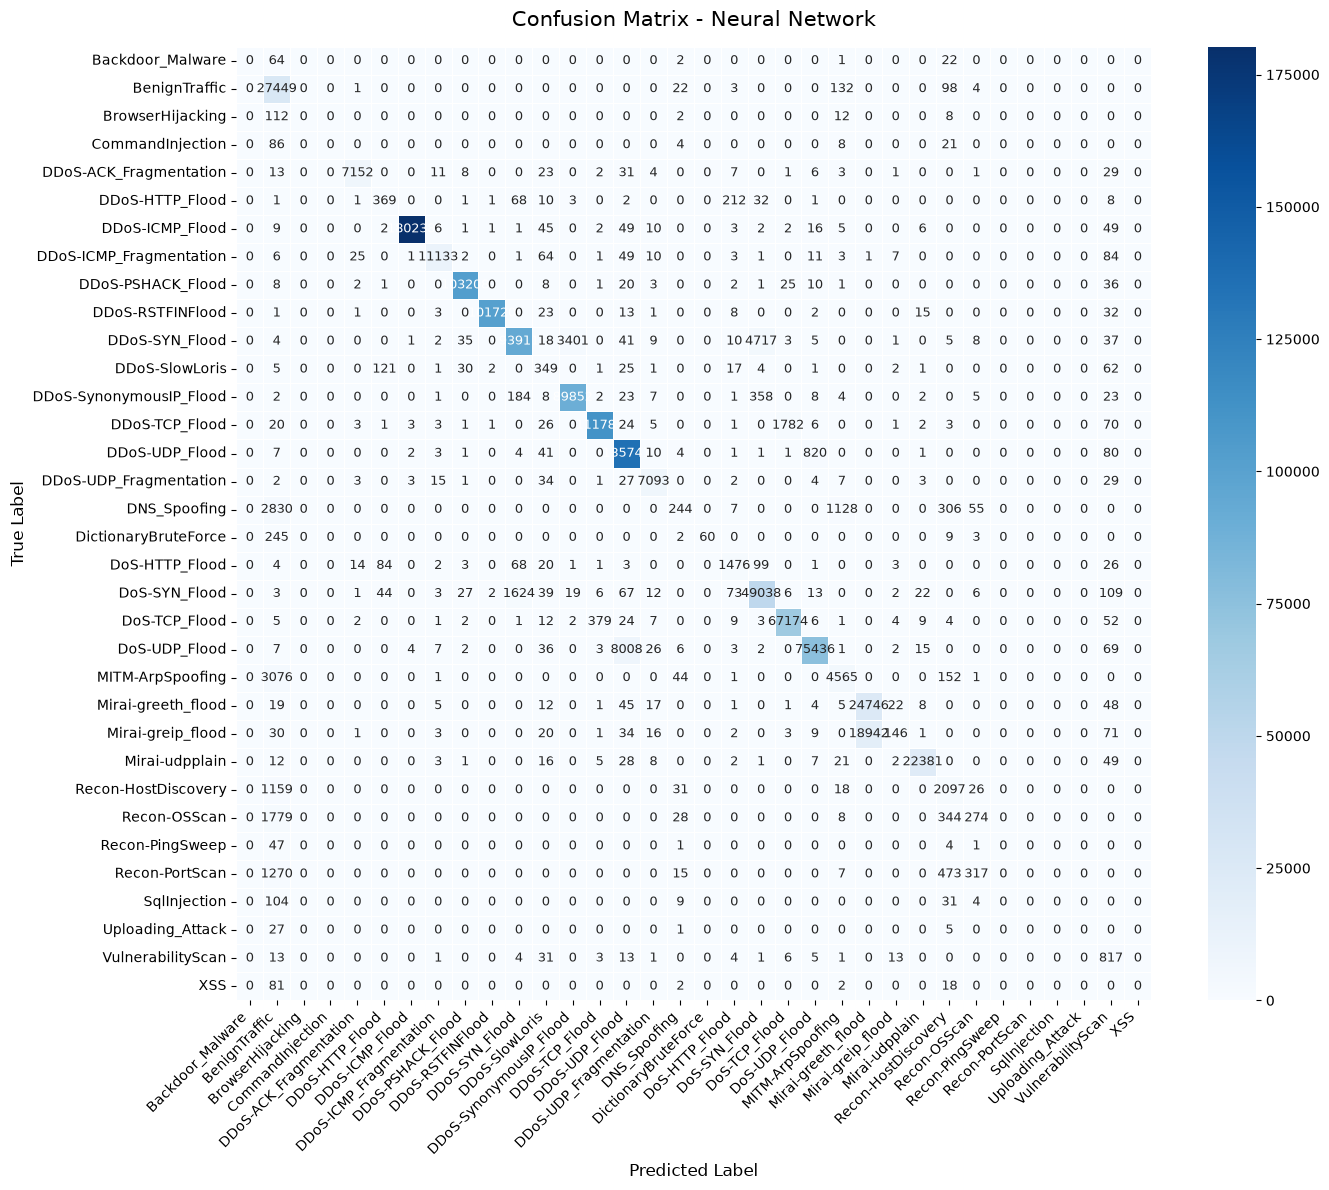

In [36]:
# Confusion Matrix
cm = confusion_matrix(
    y_test_encoded,
    y_pred_encoded
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    annot_kws={"size": 9}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Neural Network", fontsize=15, pad=15)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [29]:
#Hyperparameter experiment
def build_model(
    input_features,
    num_classes,
    neurons1=128,
    neurons2=64,
    dropout=0.30,
    learning_rate=0.001
):

    model = Sequential([
        Input(shape=(input_features,)),

        Dense(neurons1, activation="relu"),
        Dropout(dropout),

        Dense(neurons2, activation="relu"),
        Dropout(dropout),

        Dense(num_classes, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [30]:
#Run several experiments
experiments = [
    {
        "name": "Experiment 1",
        "neurons1": 64,
        "neurons2": 32,
        "dropout": 0.20,
        "learning_rate": 0.001
    },
    {
        "name": "Experiment 2",
        "neurons1": 128,
        "neurons2": 64,
        "dropout": 0.30,
        "learning_rate": 0.001
    },
    {
        "name": "Experiment 3",
        "neurons1": 256,
        "neurons2": 128,
        "dropout": 0.40,
        "learning_rate": 0.0005
    }
]

results = []

for exp in experiments:

    print("\n" + "=" * 60)
    print(exp["name"])
    print("=" * 60)

    experiment_model = build_model(
        input_features=X_train_scaled.shape[1],
        num_classes=num_classes,
        neurons1=exp["neurons1"],
        neurons2=exp["neurons2"],
        dropout=exp["dropout"],
        learning_rate=exp["learning_rate"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    experiment_model.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_val_scaled, y_val_encoded),
        epochs=15,
        batch_size=256,
        callbacks=[early_stopping],
        verbose=1
    )

    predictions = experiment_model.predict(
        X_test_scaled,
        verbose=0
    )

    predictions = np.argmax(predictions, axis=1)

    exp_accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    exp_precision = precision_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    exp_recall = recall_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    exp_f1 = f1_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Experiment": exp["name"],
        "Neurons": f'{exp["neurons1"]}-{exp["neurons2"]}',
        "Dropout": exp["dropout"],
        "Learning Rate": exp["learning_rate"],
        "Accuracy": exp_accuracy,
        "Precision": exp_precision,
        "Recall": exp_recall,
        "F1 Score": exp_f1
    })


Experiment 1
Epoch 1/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.8181 - loss: 0.4170 - val_accuracy: 0.9126 - val_loss: 0.2477
Epoch 2/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 154s 7ms/step - accuracy: 0.9198 - loss: 0.2151 - val_accuracy: 0.9750 - val_loss: 0.1017
Epoch 3/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - accuracy: 0.9481 - loss: 0.1523 - val_accuracy: 0.9772 - val_loss: 0.0769
Epoch 4/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - accuracy: 0.9560 - loss: 0.1263 - val_accuracy: 0.9774 - val_loss: 0.0772
Epoch 5/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.9629 - loss: 0.1179 - val_accuracy: 0.9760 - val_loss: 0.0774
Epoch 6/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.9612 - loss: 0.1205 - val_accuracy: 0.9744 - val_loss: 0.0762
Epoch 7/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.9633 - loss: 0.1151 - val_accuracy: 0.9754 - val_loss: 0.0775
Epoch 8/15
21454/21454 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/st

In [32]:
#Compare the experiments
results_df = pd.DataFrame(results)

print("\nHyperparameter Experiment Results:")
display(results_df)


Hyperparameter Experiment Results:


,Experiment,Neurons,Dropout,Learning Rate,Accuracy,Precision,Recall,F1 Score
0,Experiment 1,64-32,0.2,0.0010,0.982437,0.982523,0.982437,0.979956
1,Experiment 2,128-64,0.3,0.0010,0.981990,0.981264,0.981990,0.979938
2,Experiment 3,256-128,0.4,0.0005,0.983441,0.982713,0.983441,0.981305


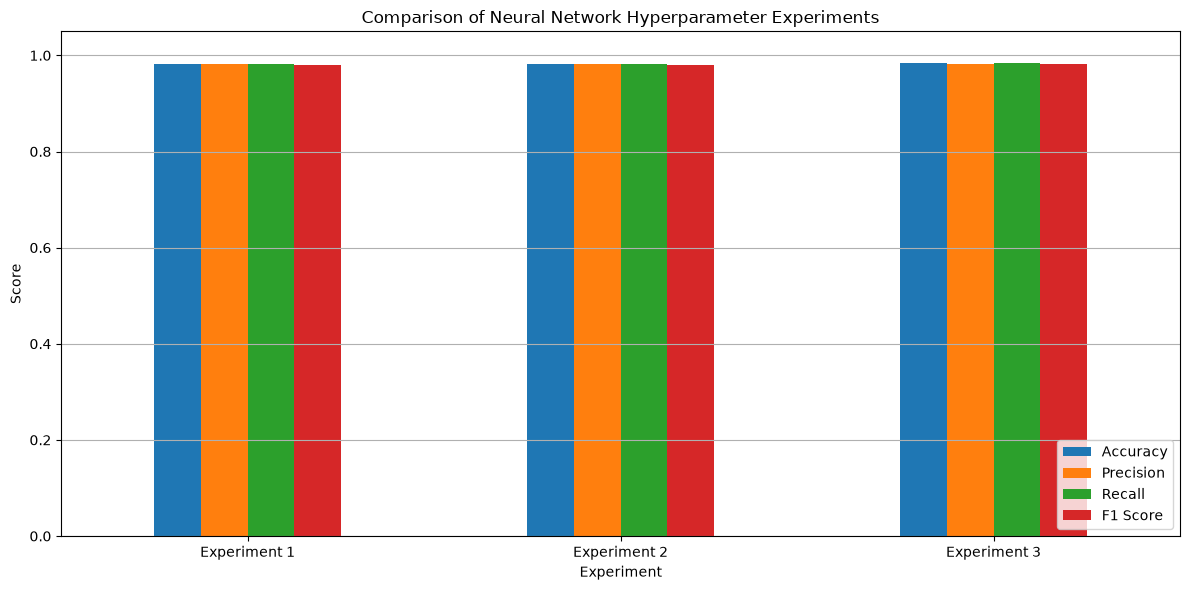

In [34]:
#Plot the hyperparameter results
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_plot = results_df.set_index("Experiment")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Neural Network Hyperparameter Experiments")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.tight_layout()



plt.show()